In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
import warnings, os, joblib
warnings.filterwarnings("ignore")
print("✅ Ready")

✅ Ready


In [2]:
DATA_PATH = "../ml-service/data/crime_data.csv"

df = pd.read_csv(DATA_PATH)

if "year" not in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year

print(f"✅ Loaded {len(df):,} records  |  Years: {sorted(df['year'].dropna().unique().astype(int).tolist())}")
print(f"📋 Columns: {list(df.columns)}")
df.head()

✅ Loaded 9,800 records  |  Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
📋 Columns: ['incident_id', 'district', 'police_division', 'crime_type', 'date', 'day_of_week', 'is_holiday', 'time_bracket', 'location_type', 'lighting_level', 'victim_gender', 'victim_age_bracket', 'prior_offenses', 'offender_drug_history', 'reported_2015_total', 'solved_2015_total', 'cleared_rate_pct', 'reported_status', 'referral_source', 'year']


,incident_id,district,police_division,crime_type,date,day_of_week,is_holiday,time_bracket,location_type,lighting_level,victim_gender,victim_age_bracket,prior_offenses,offender_drug_history,reported_2015_total,solved_2015_total,cleared_rate_pct,reported_status,referral_source,year
0,2015-COL-001,Colombo,Colombo South,Homicide,2015-01-08,Thursday,Yes,Night,Public Space,Poorly-lit,Male,35-45,0,No,568,540,95,Solved,Police,2015
1,2015-COL-002,Colombo,Nugegoda,House Breaking,2015-04-14,Tuesday,Yes,Night,Residential,Dark,Female,45-60,1,No,9245,3050,33,Under Investigation,Police,2015
2,2015-GAM-001,Gampaha,Kelaniya,Drug Offences (Heroin),2015-02-15,Sunday,No,Morning,Transport Hub,Well-lit,Male,18-24,3,Yes,26145,25000,95,Solved,Police,2015
3,2015-KAN-001,Kandy,Kandy Central,Robbery,2015-08-10,Monday,No,Evening,Commercial,Well-lit,Male,25-35,2,No,3542,2300,65,Solved,Self-Reported,2015
4,2015-KAL-001,Kalutara,Panadura,Grievous Hurt,2015-03-22,Sunday,No,Evening,Public Space,Poorly-lit,Male,25-35,1,No,1410,1290,91,Solved,Hospital,2015


In [3]:
for col in ["prior_offenses","offender_drug_history","crime_type","district","reported_status"]:
    print(f"\n{col} distribution:")
    print(df[col].value_counts().head(6))


prior_offenses distribution:
prior_offenses
1    3306
0    3143
2    1993
3    1334
4      23
5       1
Name: count, dtype: int64

offender_drug_history distribution:
offender_drug_history
No     7745
Yes    2055
Name: count, dtype: int64

crime_type distribution:
crime_type
House Breaking            1926
Drug Offences (Heroin)    1383
Robbery                   1287
Property Theft            1256
Homicide                  1246
Grievous Hurt              667
Name: count, dtype: int64

district distribution:
district
Colombo     751
Gampaha     735
Kandy       723
Jaffna      715
Kalutara    714
Galle       714
Name: count, dtype: int64

reported_status distribution:
reported_status
Solved                 9099
Under Investigation     701
Name: count, dtype: int64


✅ Repeat offenders:     6,657 (67.9%)
✅ First-time offenders: 3,143


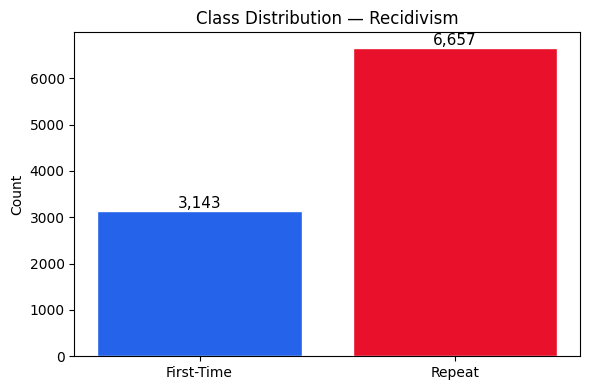

In [4]:
df["prior_offenses"] = pd.to_numeric(df["prior_offenses"], errors="coerce").fillna(0)
df["is_repeat_offender"] = (df["prior_offenses"] > 0).astype(int)

print(f"✅ Repeat offenders:     {df['is_repeat_offender'].sum():,} ({df['is_repeat_offender'].mean()*100:.1f}%)")
print(f"✅ First-time offenders: {(df['is_repeat_offender']==0).sum():,}")

plt.figure(figsize=(6, 4))
counts = df["is_repeat_offender"].value_counts()
plt.bar(["First-Time","Repeat"], [counts.get(0,0), counts.get(1,0)],
        color=["#2563eb","#e8102a"], edgecolor="white")
plt.title("Class Distribution — Recidivism")
plt.ylabel("Count")
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    plt.text(i, v + 50, f"{v:,}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("recidivism_class_balance.png", dpi=150)
plt.show()

In [5]:
le_crime    = LabelEncoder()
le_district = LabelEncoder()
le_gender   = LabelEncoder()
le_time     = LabelEncoder()
le_location = LabelEncoder()
le_lighting = LabelEncoder()
le_drug     = LabelEncoder()

df["crime_enc"]    = le_crime.fit_transform(df["crime_type"].fillna("Unknown"))
df["district_enc"] = le_district.fit_transform(df["district"].fillna("Unknown"))
df["gender_enc"]   = le_gender.fit_transform(df["victim_gender"].fillna("Unknown"))
df["time_enc"]     = le_time.fit_transform(df["time_bracket"].fillna("Unknown"))
df["location_enc"] = le_location.fit_transform(df["location_type"].fillna("Unknown"))
df["lighting_enc"] = le_lighting.fit_transform(df["lighting_level"].fillna("Unknown"))
df["drug_enc"]     = le_drug.fit_transform(df["offender_drug_history"].fillna("Unknown"))

df["is_holiday"]       = pd.to_numeric(df["is_holiday"],       errors="coerce").fillna(0)
df["cleared_rate_pct"] = pd.to_numeric(df["cleared_rate_pct"], errors="coerce").fillna(0)
df["year"]             = pd.to_numeric(df["year"],             errors="coerce").fillna(2014)

age_map = {"0-17":0,"18-25":1,"26-35":2,"36-45":3,"46-60":4,"60+":5}
df["age_enc"] = df["victim_age_bracket"].map(age_map).fillna(2)

# prior_offenses EXCLUDED — used to create the label (would cause data leakage)
FEATURES = [
    "crime_enc","district_enc","gender_enc","time_enc",
    "location_enc","lighting_enc","drug_enc",
    "is_holiday","cleared_rate_pct","age_enc","year",
]

X = df[FEATURES].fillna(0)
y = df["is_repeat_offender"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"✅ Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"📋 Features: {FEATURES}")

✅ Train: 7,840  |  Test: 1,960
📋 Features: ['crime_enc', 'district_enc', 'gender_enc', 'time_enc', 'location_enc', 'lighting_enc', 'drug_enc', 'is_holiday', 'cleared_rate_pct', 'age_enc', 'year']


In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc    = accuracy_score(y_test, y_pred)
auc    = roc_auc_score(y_test, y_proba)
cv_acc = cross_val_score(rf, X, y, cv=5, scoring="accuracy").mean()

print("=" * 45)
print(f"  Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC Score: {auc:.4f}")
print(f"  CV Accuracy:   {cv_acc:.4f}  ({cv_acc*100:.2f}%)")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["First-Time","Repeat"]))

  Test Accuracy: 0.9265  (92.65%)
  ROC-AUC Score: 0.9758
  CV Accuracy:   0.9158  (91.58%)

Classification Report:
              precision    recall  f1-score   support

  First-Time       0.82      1.00      0.90       629
      Repeat       1.00      0.89      0.94      1331

    accuracy                           0.93      1960
   macro avg       0.91      0.94      0.92      1960
weighted avg       0.94      0.93      0.93      1960



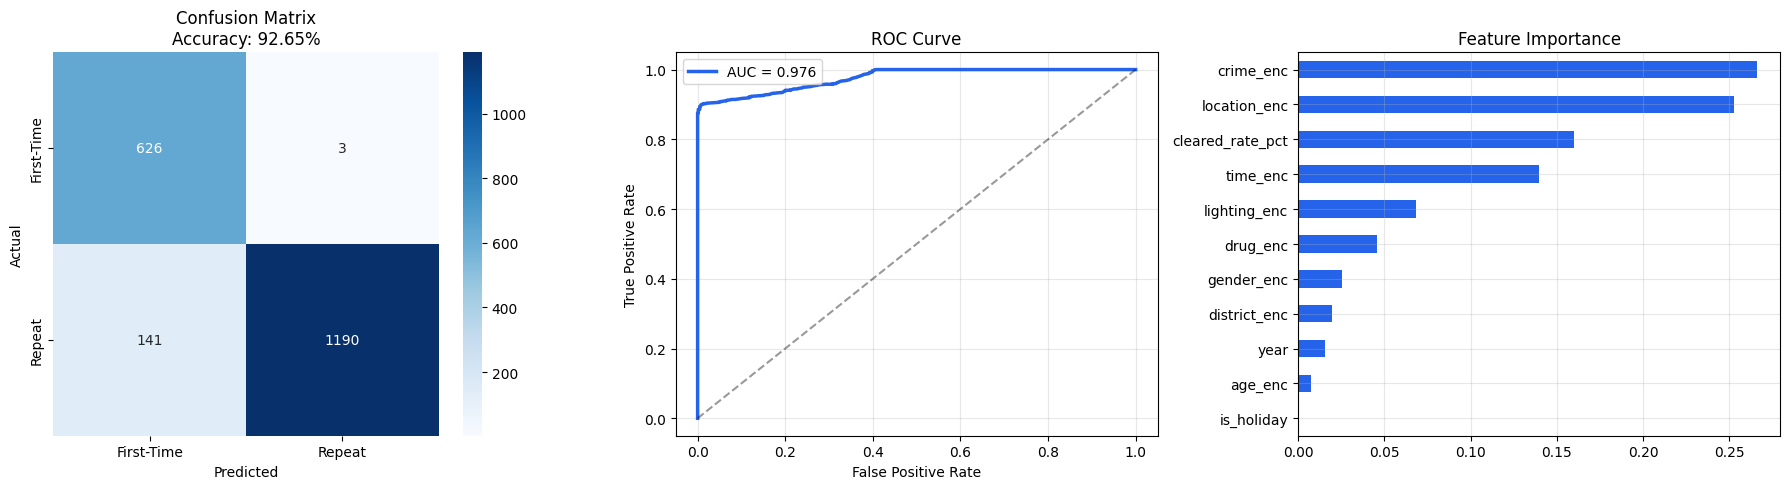

✅ Accuracy: 92.65%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["First-Time","Repeat"],
            yticklabels=["First-Time","Repeat"])
axes[0].set_title(f"Confusion Matrix\nAccuracy: {acc*100:.2f}%")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#2563eb", linewidth=2.5, label=f"AUC = {auc:.3f}")
axes[1].plot([0,1],[0,1], "k--", alpha=0.4)
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importance.plot(kind="barh", ax=axes[2], color="#2563eb")
axes[2].set_title("Feature Importance"); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("recidivism_results.png", dpi=150)
plt.show()
print(f"✅ Accuracy: {acc*100:.2f}%")

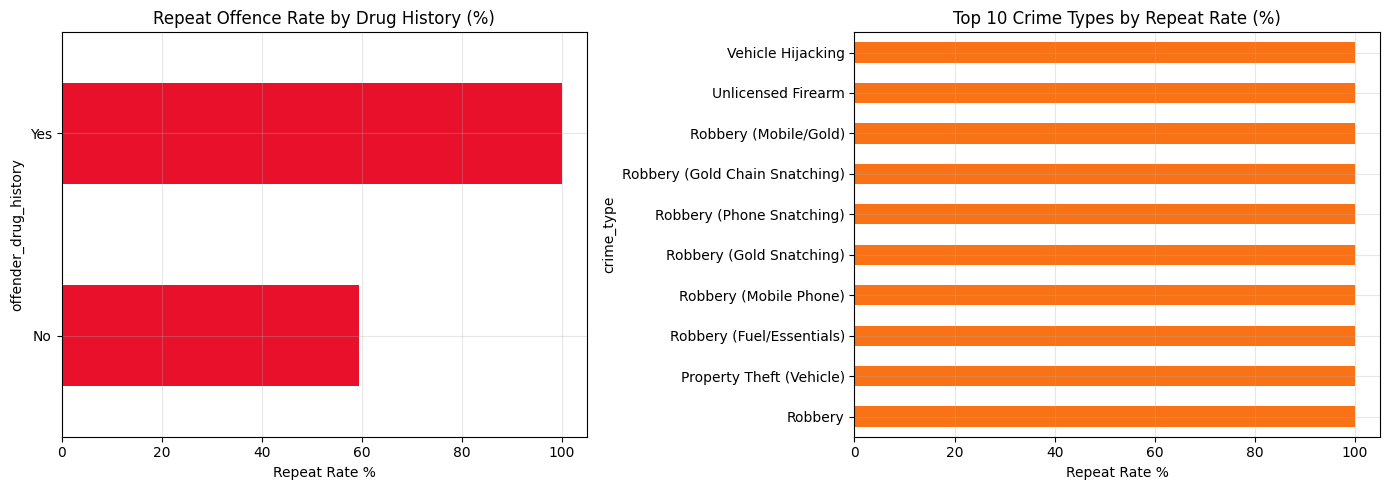

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

drug_repeat = df.groupby("offender_drug_history")["is_repeat_offender"].mean() * 100
drug_repeat.sort_values().plot(kind="barh", ax=axes[0], color="#e8102a")
axes[0].set_title("Repeat Offence Rate by Drug History (%)")
axes[0].set_xlabel("Repeat Rate %"); axes[0].grid(True, alpha=0.3)

crime_repeat = df.groupby("crime_type")["is_repeat_offender"].mean() * 100
crime_repeat.sort_values().tail(10).plot(kind="barh", ax=axes[1], color="#f97316")
axes[1].set_title("Top 10 Crime Types by Repeat Rate (%)")
axes[1].set_xlabel("Repeat Rate %"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("recidivism_risk_analysis.png", dpi=150)
plt.show()

In [9]:
os.makedirs("./trained", exist_ok=True)

joblib.dump(rf,          "./trained/recidivism_rf.pkl")
joblib.dump(le_crime,    "./trained/le_crime.pkl")
joblib.dump(le_district, "./trained/le_district.pkl")
joblib.dump(le_gender,   "./trained/le_gender.pkl")
joblib.dump(le_time,     "./trained/le_time.pkl")
joblib.dump(le_location, "./trained/le_location.pkl")
joblib.dump(le_lighting, "./trained/le_lighting.pkl")
joblib.dump(le_drug,     "./trained/le_drug.pkl")
joblib.dump(FEATURES,    "./trained/rf_features.pkl")

print("✅ All models saved → ./trained/")
print(f"🎯 Final Accuracy: {acc*100:.2f}%")

✅ All models saved → ./trained/
🎯 Final Accuracy: 92.65%
